In [1]:
from IPython.utils import io

with io.capture_output():
    %run ../01_eda_exploratory_data_analysis/01_data_overview.ipynb
    %run ../01_eda_exploratory_data_analysis/02_statistical_analysis.ipynb
    %run ../01_eda_exploratory_data_analysis/03_correlation_analysis.ipynb

print("✅ Connected to notebooks")

✅ Connected to notebooks


###  Price Line Chart

📈 PRICE LINE CHART


NameError: name 'DateFormatter' is not defined

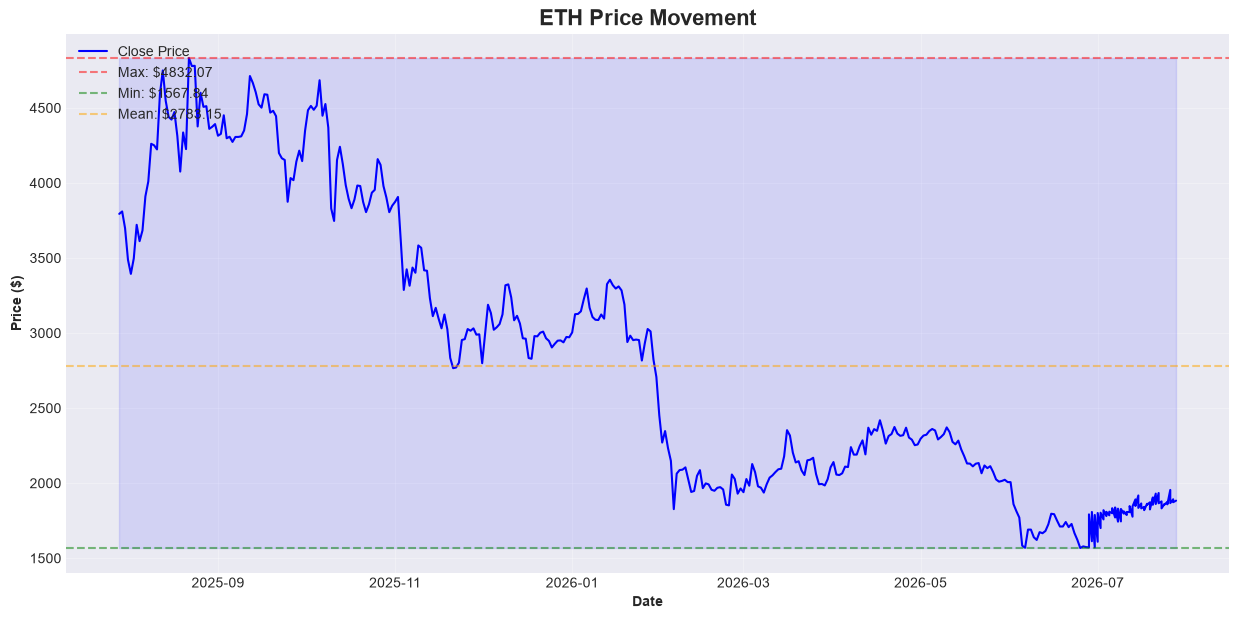

In [2]:
# ====================================================================
# 📈 PRICE LINE CHART
# ====================================================================

print("=" * 60)
print("📈 PRICE LINE CHART")
print("=" * 60)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot price line
ax.plot(df.index, df[price_col], linewidth=1.5, color='blue', label='Close Price')

# Add horizontal lines for min and max
ax.axhline(y=df[price_col].max(), color='red', linestyle='--', alpha=0.5, 
           label=f'Max: ${df[price_col].max():.2f}')
ax.axhline(y=df[price_col].min(), color='green', linestyle='--', alpha=0.5, 
           label=f'Min: ${df[price_col].min():.2f}')
ax.axhline(y=df[price_col].mean(), color='orange', linestyle='--', alpha=0.5, 
           label=f'Mean: ${df[price_col].mean():.2f}')

# Fill between min and max
ax.fill_between(df.index, df[price_col].min(), df[price_col].max(), 
                alpha=0.1, color='blue')

# Formatting
ax.set_title('ETH Price Movement', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(15))

plt.tight_layout()
plt.show()

print("\n✅ Price line chart displayed")

###  Price with Moving Averages

📊 PRICE WITH MOVING AVERAGES


NameError: name 'DateFormatter' is not defined

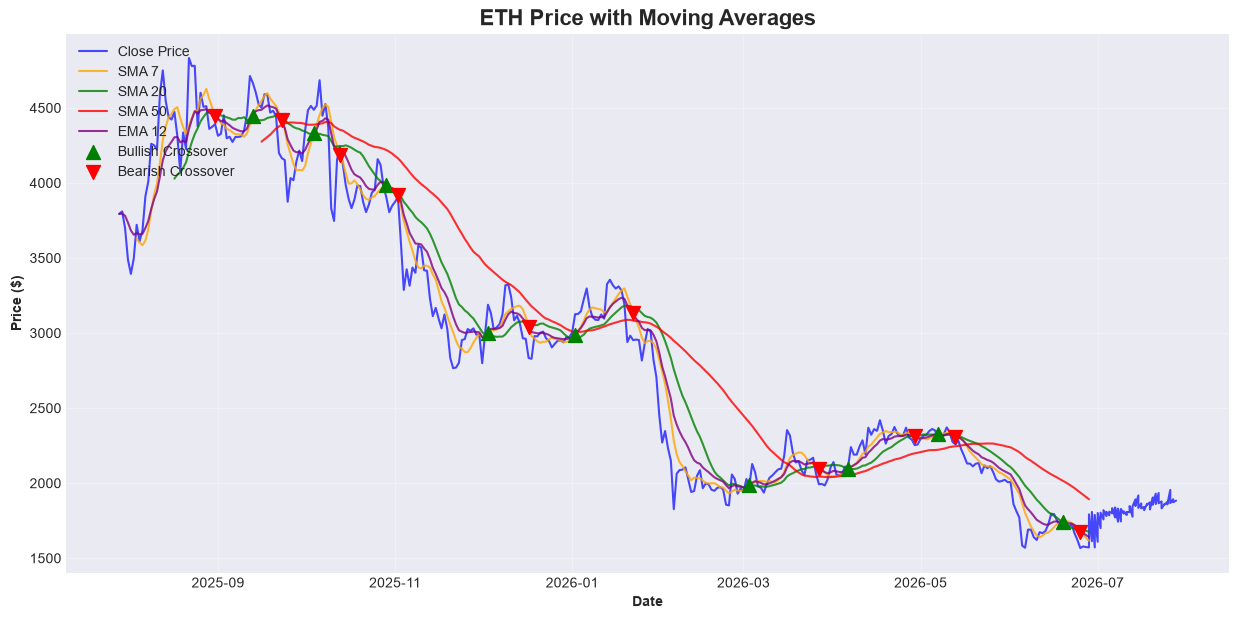

In [3]:
# ====================================================================
# 📊 PRICE WITH MOVING AVERAGES
# ====================================================================

print("=" * 60)
print("📊 PRICE WITH MOVING AVERAGES")
print("=" * 60)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot price
ax.plot(df.index, df[price_col], linewidth=1.5, color='blue', label='Close Price', alpha=0.7)

# Add moving averages
if 'SMA_7' in df.columns:
    ax.plot(df.index, df['SMA_7'], linewidth=1.5, color='orange', label='SMA 7', alpha=0.8)
if 'SMA_20' in df.columns:
    ax.plot(df.index, df['SMA_20'], linewidth=1.5, color='green', label='SMA 20', alpha=0.8)
if 'SMA_50' in df.columns:
    ax.plot(df.index, df['SMA_50'], linewidth=1.5, color='red', label='SMA 50', alpha=0.8)
if 'EMA_12' in df.columns:
    ax.plot(df.index, df['EMA_12'], linewidth=1.5, color='purple', label='EMA 12', alpha=0.8)

# Add crossover points (if SMA_7 and SMA_20 exist)
if 'SMA_7' in df.columns and 'SMA_20' in df.columns:
    # Find crossovers
    crossover = (df['SMA_7'] > df['SMA_20']) & (df['SMA_7'].shift(1) <= df['SMA_20'].shift(1))
    crossunder = (df['SMA_7'] < df['SMA_20']) & (df['SMA_7'].shift(1) >= df['SMA_20'].shift(1))
    
    # Mark crossovers
    ax.scatter(df.index[crossover], df['SMA_7'][crossover], 
              color='green', s=100, marker='^', label='Bullish Crossover', zorder=5)
    ax.scatter(df.index[crossunder], df['SMA_7'][crossunder], 
              color='red', s=100, marker='v', label='Bearish Crossover', zorder=5)

# Formatting
ax.set_title('ETH Price with Moving Averages', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(15))

plt.tight_layout()
plt.show()

print("\n✅ Price with moving averages displayed")

###  Candlestick-like Chart (Simplified)

📊 CANDLESTICK-LIKE CHART


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

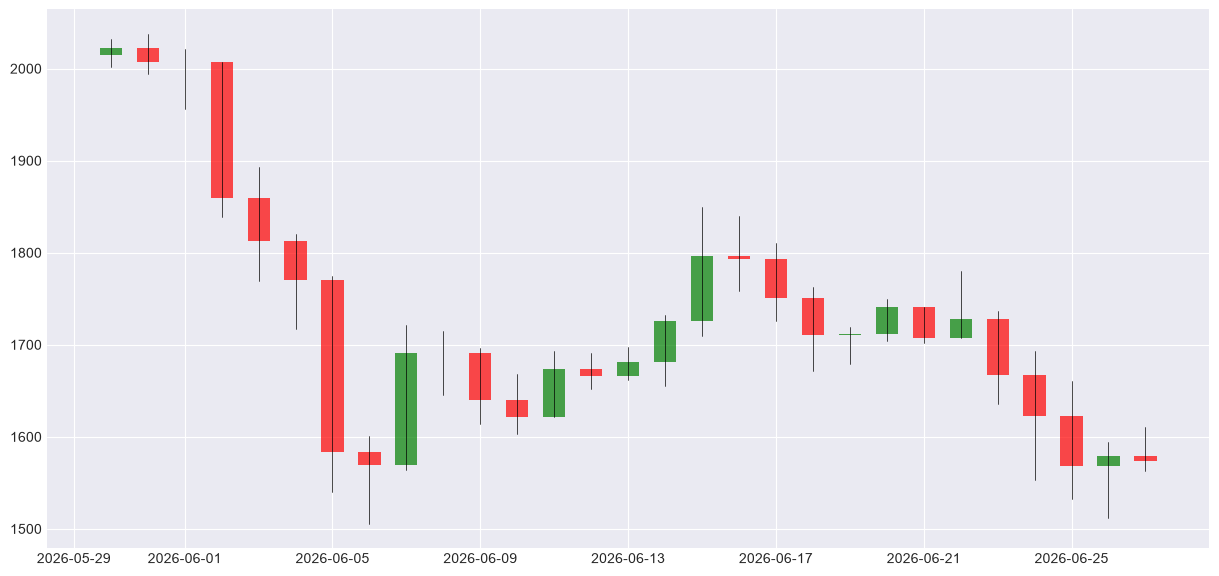

In [4]:
# ====================================================================
# 📊 CANDLESTICK-LIKE CHART (Simplified)
# ====================================================================

print("=" * 60)
print("📊 CANDLESTICK-LIKE CHART")
print("=" * 60)

# Use only last 90 days for better visibility
if len(df) > 90:
    plot_df = df.iloc[-90:]
else:
    plot_df = df

fig, ax = plt.subplots(figsize=(15, 7))

# Plot candles as vertical lines with markers
for i, idx in enumerate(plot_df.index):
    # Body color
    if plot_df.loc[idx, 'close'] >= plot_df.loc[idx, 'open']:
        color = 'green'
    else:
        color = 'red'
    
    # Plot the high-low line (wick)
    ax.plot([idx, idx], [plot_df.loc[idx, 'low'], plot_df.loc[idx, 'high']], 
            color='black', linewidth=0.5)
    
    # Plot the open-close body
    body_bottom = min(plot_df.loc[idx, 'open'], plot_df.loc[idx, 'close'])
    body_top = max(plot_df.loc[idx, 'open'], plot_df.loc[idx, 'close'])
    ax.bar(idx, body_top - body_bottom, bottom=body_bottom, 
           color=color, width=0.6, alpha=0.7)

# Add price line overlay
ax.plot(plot_df.index, plot_df[price_col], linewidth=1.5, color='blue', alpha=0.5, label='Close Price')

# Formatting
ax.set_title('ETH Candlestick Pattern (Last 90 Days)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(20))

plt.tight_layout()
plt.show()

print("\n✅ Candlestick chart displayed")

### Price Patterns - Support & Resistance

📊 SUPPORT & RESISTANCE LEVELS


NameError: name 'DateFormatter' is not defined

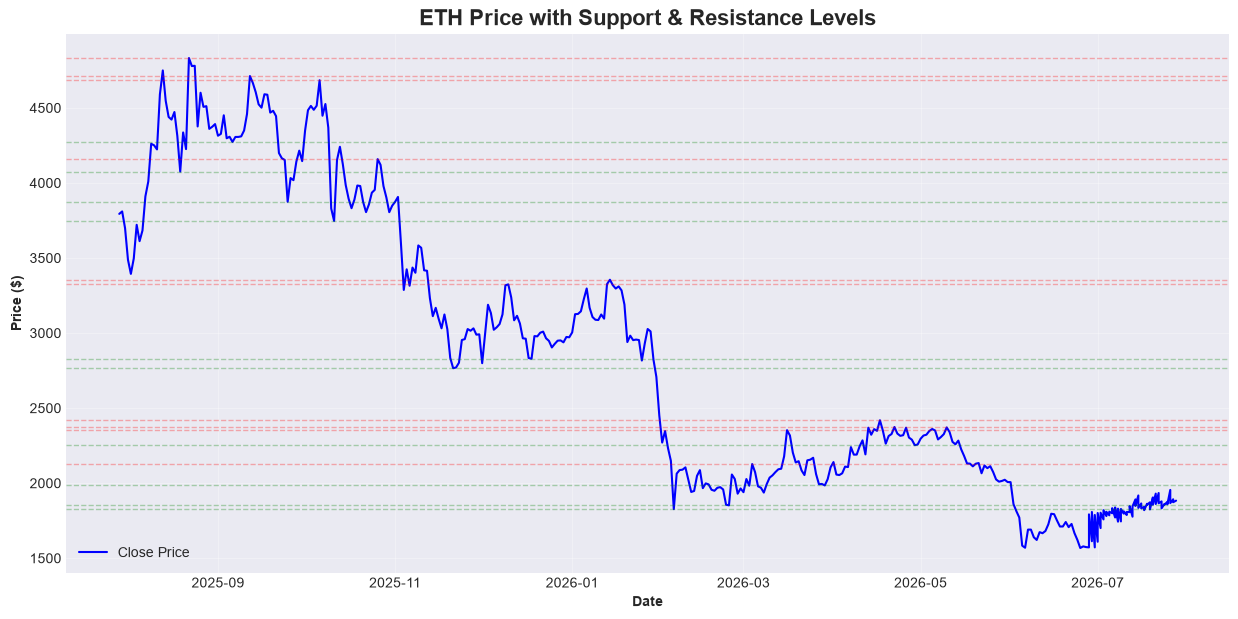

In [5]:
# ====================================================================
# 📊 SUPPORT & RESISTANCE LEVELS
# ====================================================================

print("=" * 60)
print("📊 SUPPORT & RESISTANCE LEVELS")
print("=" * 60)

fig, ax = plt.subplots(figsize=(15, 7))

# Plot price
ax.plot(df.index, df[price_col], linewidth=1.5, color='blue', label='Close Price')

# Calculate support and resistance levels (simple method)
# Resistance: local maxima
window = 20
rolling_max = df[price_col].rolling(window=window, center=True).max()
rolling_min = df[price_col].rolling(window=window, center=True).min()

# Find support and resistance
resistance_points = []
support_points = []

for i in range(window, len(df) - window):
    if df[price_col].iloc[i] == rolling_max.iloc[i]:
        resistance_points.append(i)
    if df[price_col].iloc[i] == rolling_min.iloc[i]:
        support_points.append(i)

# Plot support and resistance lines
if resistance_points:
    for point in resistance_points[:10]:  # Limit to 10 points
        ax.axhline(y=df[price_col].iloc[point], color='red', linestyle='--', alpha=0.3, linewidth=1)
        
# Plot support lines
if support_points:
    for point in support_points[:10]:  # Limit to 10 points
        ax.axhline(y=df[price_col].iloc[point], color='green', linestyle='--', alpha=0.3, linewidth=1)

# Formatting
ax.set_title('ETH Price with Support & Resistance Levels', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Price ($)', fontweight='bold')
ax.legend(['Close Price'])
ax.grid(True, alpha=0.3)

# Format x-axis dates
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(plt.MaxNLocator(15))

plt.tight_layout()
plt.show()

print("\n✅ Support & resistance chart displayed")

###  Price Patterns - Trend Lines